In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import torch
np.random.seed(42)
torch.manual_seed(42)

In [3]:
file_path = "../data/mariel_betternot_and_retrograde.npy"  # Replace with your data file
def preprocesss(file_path,seq_len=50):
    dat = np.load(file_path)[:,4000:8000,:] 
    data = dat.transpose(1, 0, 2)  
    point_mask = np.ones(55, dtype=bool)
    point_mask[[26,53]] = False
    data = data[:, point_mask, :]  # Now (timesteps, 53, 3)
    
    # Invert Z-axis (matching original processing)
    data[..., 2] *= -1
    data = data.reshape(data.shape[0]//seq_len, seq_len, 53*3)
    data = torch.tensor(data,dtype=torch.float)
    return data

In [5]:
data=preprocesss(file_path)
data.shape

torch.Size([80, 50, 159])

100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:01<00:00, 45.52it/s]


Saved animate/temppp.gif and animate/temppp.mp4


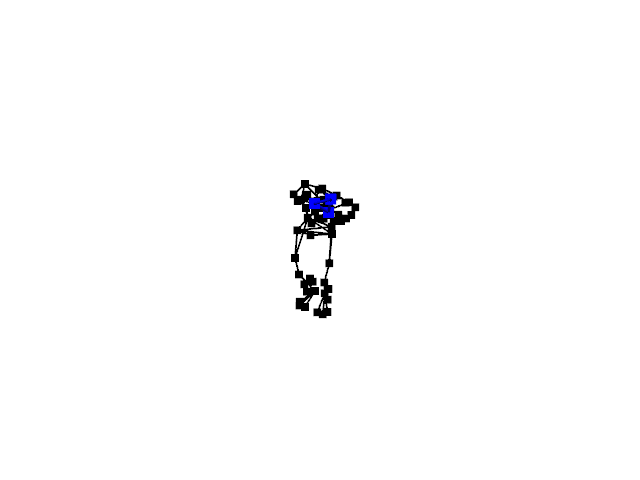

In [7]:
#labels and skeleton connections (from original code)
point_labels = ['ARIEL', 'C7', 'CLAV', 'LANK', 'LBHD', 'LBSH', 'LBWT', 'LELB', 'LFHD', 'LFRM', 
                'LFSH', 'LFWT', 'LHEL', 'LIEL', 'LIHAND', 'LIWR', 'LKNE', 'LKNI', 'LMT1', 'LMT5', 
                'LOHAND', 'LOWR', 'LSHN', 'LTHI', 'LTOE', 'LUPA', 'MBWT', 'MFWT', 'RANK', 'RBHD', 
                'RBSH', 'RBWT', 'RELB', 'RFHD', 'RFRM', 'RFSH', 'RFWT', 'RHEL', 'RIEL', 'RIHAND', 
                'RIWR', 'RKNE', 'RKNI', 'RMT1', 'RMT5', 'ROHAND', 'ROWR', 'RSHN', 'RTHI', 'RTOE', 
                'RUPA', 'STRN', 'T10']
skeleton_lines = [
    (('LHEL',), ('LTOE',)), (('RHEL',), ('RTOE',)), (('LMT1',), ('LMT5',)), (('RMT1',), ('RMT5',)),
    (('LHEL',), ('LMT1',)), (('LHEL',), ('LMT5',)), (('RHEL',), ('RMT1',)), (('RHEL',), ('RMT5',)),
    (('LTOE',), ('LMT1',)), (('LTOE',), ('LMT5',)), (('RTOE',), ('RMT1',)), (('RTOE',), ('RMT5',)),
    (('LKNE',), ('LHEL',)), (('RKNE',), ('RHEL',)), (('LFWT',), ('RBWT',)), (('RFWT',), ('LBWT',)),
    (('LFWT',), ('RFWT',)), (('LBWT',), ('RBWT',)), (('LFWT',), ('LBWT',)), (('RFWT',), ('RBWT',)),
    (('LFWT',), ('LTHI',)), (('RFWT',), ('RTHI',)), (('LBWT',), ('LTHI',)), (('RBWT',), ('RTHI',)),
    (('LKNE',), ('LTHI',)), (('RKNE',), ('RTHI',)), 
    (('CLAV',), ('RFSH',)),
    (('STRN',), ('LFSH',)), (('STRN',), ('RFSH',)), (('T10',), ('LFSH',)), (('T10',), ('RFSH',)),
    (('C7',), ('LBSH',)), (('C7',), ('RBSH',)), (('LFSH',), ('LBSH',)), (('RFSH',), ('RBSH',)),
    (('LFSH',), ('RBSH',)), (('RFSH',), ('LBSH',)), (('LFSH',), ('LUPA',)), (('RFSH',), ('RUPA',)),
    (('LBSH',), ('LUPA',)), (('RBSH',), ('RUPA',)), (('LIWR',), ('LIHAND',)), (('RIWR',), ('RIHAND',)),
    (('LOWR',), ('LOHAND',)), (('ROWR',), ('ROHAND',)), (('LIWR',), ('LOWR',)), (('RIWR',), ('ROWR',)),
    (('LIHAND',), ('LOHAND',)), (('RIHAND',), ('ROHAND',)), (('LFHD',), ('LBHD',)), (('LBHD',), ('RBHD',)),
    (('RBHD',), ('RFHD',)), (('RFHD',), ('LFHD',)), (('LFHD',), ('ARIEL',)), (('LBHD',), ('ARIEL',)),
    (('RBHD',), ('ARIEL',)), 
    (('RFHD',), ('ARIEL',)),
    (('RFWT',), ('MFWT',)),(('LFWT',), ('MFWT',)),(('LFSH',), ('RFSH',)) # added 
]
# from pirounet paper simpler representation
skeleton_lines2 = [
    #     ( (start group), (end group) ),
    (("LHEL",), ("LTOE",)),  # toe to heel
    (("RHEL",), ("RTOE",)),
    (("LKNE", "LKNI"), ("LHEL",)),  # heel to knee
    (("RKNE", "RKNI"), ("RHEL",)),
    (("LKNE", "LKNI"), ("LFWT", "RFWT", "LBWT", "RBWT")),  # knee to "navel"
    (("RKNE", "RKNI"), ("LFWT", "RFWT", "LBWT", "RBWT")),
    (
        ("LFWT", "RFWT", "LBWT", "RBWT"),
        (
            "STRN",
            "T10",
        ),
    ),  # "navel" to chest
    (
        (
            "STRN",
            "T10",
        ),
        (
            "CLAV",
            "C7",
        ),
    ),  # chest to neck
    (
        (
            "CLAV",
            "C7",
        ),
        (
            "LFSH",
            "LBSH",
        ),
    ),  # neck to shoulders
    (
        (
            "CLAV",
            "C7",
        ),
        (
            "RFSH",
            "RBSH",
        ),
    ),
    (
        (
            "LFSH",
            "LBSH",
        ),
        (
            "LELB",
            "LIEL",
        ),
    ),  # shoulders to elbows
    (
        (
            "RFSH",
            "RBSH",
        ),
        (
            "RELB",
            "RIEL",
        ),
    ),
    (
        (
            "LELB",
            "LIEL",
        ),
        (
            "LOWR",
            "LIWR",
        ),
    ),  # elbows to wrist
    (
        (
            "RELB",
            "RIEL",
        ),
        (
            "ROWR",
            "RIWR",
        ),
    ),
    (("LFHD",), ("LBHD",)),  # draw lines around circumference of the head
    (("LBHD",), ("RBHD",)),
    (("RBHD",), ("RFHD",)),
    (("RFHD",), ("LFHD",)),
    (("LFHD",), ("ARIEL",)),  # connect circumference points to top of head
    (("LBHD",), ("ARIEL",)),
    (("RBHD",), ("ARIEL",)),
    (("RFHD",), ("ARIEL",)),
]

reduced_joint_names = [
    'ARIEL', 'C7', 'CLAV', 'STRN',  # Head & Spine
    'RFSH', 'LFSH', 'RBSH', 'LBSH',  # Shoulders
    'RIEL', 'LIEL', 'RIWR', 'LIWR',  # Elbows & Wrists
    'RKNE', 'LKNE', 'RTOE', 'LTOE',  # Knees & Toes
    'RHEL', 'LHEL',  # Heels
    'RFWT', 'LFWT', 'RBWT', 'LBWT',  # Hip/Pelvis
    'RTHI', 'LTHI', 'RSHN', 'LSHN'  # Thighs & Shins
]
def create_skeleton(points, labels, connections, show_points=True, reduced_joint_names=None):
    label_to_idx = {label: i for i, label in enumerate(labels)}
    valid_indices = (np.arange(len(labels)) if reduced_joint_names is None 
                     else np.array([label_to_idx[j] for j in reduced_joint_names if j in label_to_idx]))
    if len(valid_indices) < 2:
        raise ValueError("At least two valid joints are needed.")
    
    index_map = {old: new for new, old in enumerate(valid_indices)}
    
    lines = np.hstack([[2, index_map[s], index_map[e]] 
                      for a, b in connections 
                      if (s := label_to_idx.get(a[0])) in index_map 
                      and (e := label_to_idx.get(b[0])) in index_map]).astype(np.int32)
    
    mesh = pv.PolyData(np.asarray(points)[valid_indices])
    if lines.size > 0:
        mesh.lines = lines
    
    return mesh, 10 if show_points else 0
def create_skeleton2(points, show_points=True): #for face triangle colour
    points = np.array(points)
    if points.shape[1] != 3 or len(points) < 2:
        raise ValueError("Points must have shape (N,3) with at least two points.")
    lines = np.array([(2, i, i + 1) for i in range(len(points) - 1)], dtype=np.int32).flatten()
    if len(points) == 3:
        lines = np.append(lines, [2, 2, 0])

    mesh = pv.PolyData(points)
    if lines.size > 0:
        mesh.lines = lines

    return mesh, 10 if show_points else 0
import os
import numpy as np
import cv2
import pyvista as pv
import imageio.v2 as iio
from tqdm import tqdm

def generate_skeleton_animation(data, output_name="skeleton_animation", stride=1, fps=24):
    plotter = pv.Plotter(off_screen=True, window_size=(640, 480))  

    label_to_idx = {label: idx for idx, label in enumerate(point_labels)}
    head_indices = np.array([0, 8, 33])  

    all_points = data.reshape(-1, data.shape[-1])
    global_min = all_points.min(axis=0)
    global_max = all_points.max(axis=0)
    global_center = (global_min + global_max) / 2
    global_diagonal = np.linalg.norm(global_max - global_min)
    global_view_distance = global_diagonal * 1.5

    camera_position = [
        global_center[0] + global_view_distance * 0.5,
        global_center[1] + global_view_distance * 0.3,
        global_center[2] + global_view_distance * 0.4
    ]

    plotter.camera_position = [camera_position, global_center, [0, 0, 1]]
    plotter.reset_camera()
    plotter.camera.zoom(2.0) 
    prev_frame = data[0]
    start_saving = False  
    movement_threshold = 0.001 * global_diagonal  
    total_frames = min(data.shape[0], 1500)  

    output_gif = f"{output_name}.gif"
    output_mp4 = f"{output_name}.mp4"

    with iio.get_writer(output_gif, mode="I", duration=int(1000 / fps)) as gif_writer:
        video_writer = None

        for t in tqdm(range(0, total_frames, stride)):
            current_frame = data[t]
            movement = np.linalg.norm(current_frame - prev_frame)

            if movement > movement_threshold or t > 0:
                start_saving = True 

            if start_saving:
                frame_center = current_frame.mean(axis=0)
                camera_position = [
                    frame_center[0] + global_view_distance * 0.5,
                    frame_center[1] + global_view_distance * 0.3,
                    frame_center[2] + global_view_distance * 0.4
                ]
                plotter.camera_position = [camera_position, frame_center, [0, 0, 1]]

                mesh, point_size = create_skeleton(current_frame, point_labels, skeleton_lines, show_points=True)
                mesh2, point_size2 = create_skeleton2(current_frame[head_indices], show_points=True)
                # point_size=0
                # point_size2=0
                plotter.add_mesh(mesh, render_lines_as_tubes=True, line_width=2, point_size=point_size/1.25 , color='black')
                plotter.add_mesh(mesh2, render_lines_as_tubes=True, line_width=3, point_size=point_size2 * 1.1, color='red')

                img = plotter.screenshot(return_img=True)
                frame = cv2.cvtColor(img, cv2.COLOR_RGBA2BGR)

                gif_writer.append_data(frame)

                if video_writer is None:
                    height, width, _ = frame.shape
                    video_writer = cv2.VideoWriter(output_mp4, cv2.VideoWriter_fourcc(*'mp4v'), fps, (width, height))

                video_writer.write(frame)
                plotter.clear_actors()

            prev_frame = current_frame  

            if t % 100 == 0:
                plotter.close()
                del plotter
                plotter = pv.Plotter(off_screen=True, window_size=(640, 480))  
                plotter.camera_position = [camera_position, global_center, [0, 0, 1]]
                plotter.camera.zoom(0.50) 

        if video_writer:
            video_writer.release()

    plotter.close()
    del plotter  

    print(f"Saved {output_gif} and {output_mp4}")
def visualize(one_seq,filename='temppp'):
    path = os.path.join("animate", f"{filename}")
    inp = np.array(one_seq.detach().reshape(one_seq.shape[0],53,3))
    # print(inp.shape)
    generate_skeleton_animation(inp,output_name=path)
visualize(data[1])
from IPython.display import Image
Image(filename='animate/temppp.gif')

In [9]:
data[1].shape

torch.Size([50, 159])

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

class MotionAutoencoder(nn.Module):
    def __init__(self, seq_len=40, input_dim=159, latent_dim=64):
        super(MotionAutoencoder, self).__init__()
        
        self.seq_len = seq_len
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        self.encoder = nn.Sequential(
            nn.Linear(seq_len * input_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, seq_len * input_dim)
        )
    
    def forward(self, x):
        batch_size = x.shape[0]
        x = x.reshape(batch_size, -1)
        
        z = self.encoder(x)
        reconstruction = self.decoder(z)
        reconstruction = reconstruction.reshape(batch_size, self.seq_len, self.input_dim)
        
        return reconstruction, z
    
    def encode(self, x):
        batch_size = x.shape[0]
        x = x.reshape(batch_size, -1)
        return self.encoder(x)
    
    def decode(self, z):
        batch_size = z.shape[0]
        reconstruction = self.decoder(z)
        return reconstruction.reshape(batch_size, self.seq_len, self.input_dim)

def train_autoencoder(model, data, epochs=100, batch_size=16, learning_rate=1e-3, model_path="best_autoencoder.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    num_samples = data.shape[0]
    num_batches = num_samples // batch_size
    best_loss = float('inf')  # Track minimum loss
    
    for epoch in range(epochs):
        total_loss = 0
        
        indices = np.random.permutation(num_samples)
        data = data[indices]
        
        for i in range(num_batches):
            start_idx = i * batch_size
            end_idx = min(start_idx + batch_size, num_samples)
            
            batch_data = torch.tensor(data[start_idx:end_idx], dtype=torch.float32).to(device)
            
            optimizer.zero_grad()
            reconstruction, _ = model(batch_data)
            loss = criterion(reconstruction, batch_data)
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / num_batches

        # Save the model if loss improves
        if avg_loss < best_loss:
            best_loss = avg_loss
            # torch.save(model.state_dict(), model_path)
            if epoch%100==0:
                print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.6f} , (Saved)")
        else:
            if epoch%100==0:
                print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.6f}")
    
    return model

In [673]:
motion_data = data
model = MotionAutoencoder(seq_len=50, input_dim=159, latent_dim=32)

In [681]:
trained_model = train_autoencoder(trained_model, motion_data, epochs=1000,batch_size=64,learning_rate=1e-4,model_path='best_autoencoder_16.pth')

Epoch 1/1000, Loss: 0.005819 , (Saved)
Epoch 101/1000, Loss: 0.004943 , (Saved)
Epoch 201/1000, Loss: 0.005085
Epoch 301/1000, Loss: 0.004553
Epoch 401/1000, Loss: 0.003722
Epoch 501/1000, Loss: 0.003624
Epoch 601/1000, Loss: 0.002973
Epoch 701/1000, Loss: 0.002690
Epoch 801/1000, Loss: 0.002369
Epoch 901/1000, Loss: 0.001892


In [661]:
torch.save(trained_model.state_dict(),'best_autoencoder_32.pth')

100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 63.97it/s]


Saved animate/original.gif and animate/original.mp4


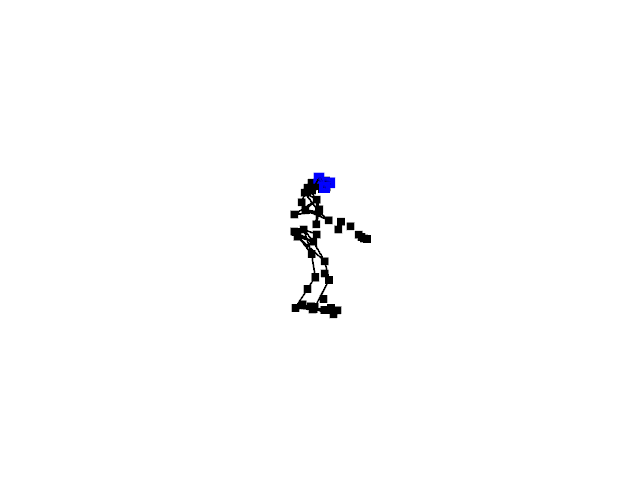

In [102]:
visualize(motion_data[0],filename='original')
Image(filename='animate/original.gif')

In [106]:
model.load_state_dict(torch.load('best_autoencoder_8.pth'))
print("Best model loaded.")

Best model loaded.


In [108]:
final_model = model
final_model.encode(motion_data[0:1]).shape

torch.Size([1, 8])

In [320]:
motion_data.shape

torch.Size([80, 50, 159])

In [324]:
# data==motion_data

100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 79.78it/s]


Saved animate/reconstructed.gif and animate/reconstructed.mp4


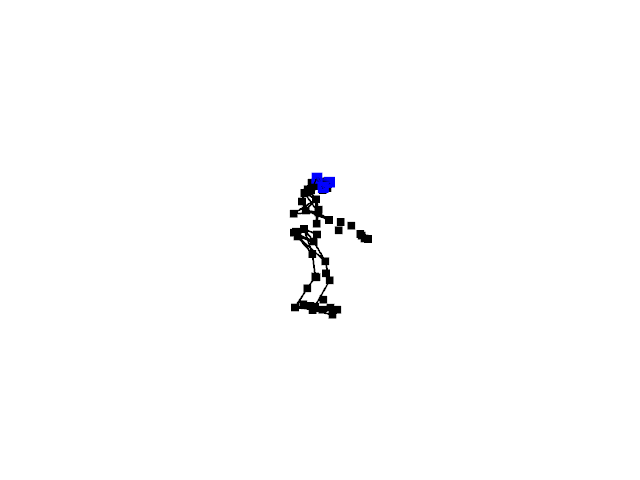

In [110]:
rec = final_model.decode(final_model.encode(motion_data[0:1])).squeeze(0)
visualize(rec,filename='reconstructed')
Image(filename='animate/reconstructed.gif')

In [112]:
data.shape

torch.Size([80, 50, 159])

In [114]:
# so i have 80 data i will label 10 of them 

In [120]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def get_embeddings(model, data):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()
    
    with torch.no_grad():
        data_tensor = torch.tensor(data, dtype=torch.float32).to(device)
        embeddings = model.encode(data_tensor).cpu().numpy()
    
    return embeddings


def augment_data(data, num_augmentations=5):
    augmented_data = []
    augmented_labels = []
    
    for i, (sequence, label) in enumerate(data):
        augmented_data.append(sequence)
        augmented_labels.append(label)
        
        for j in range(num_augmentations):
            # Time warping (slight stretching/compressing)
            time_factor = np.random.uniform(0.9, 1.1)
            warped = np.zeros_like(sequence)
            for t in range(sequence.shape[0]):
                src_t = min(int(t * time_factor), sequence.shape[0] - 1)
                warped[t] = sequence[src_t]
            
            # Slight random noise
            noise = np.random.normal(0, 0.02, sequence.shape)
            augmented = warped + noise
            
            augmented_data.append(augmented)
            augmented_labels.append(label)
    
    return np.array(augmented_data), np.array(augmented_labels)


def semi_supervised_labeling(dance_sequences, manual_labels):
    # Assume dance_sequences.shape = (80, 50, 159)
    # Assume manual_labels is a list of 10 labels corresponding to the first 10 sequences
    print(f"Total sequences: {len(dance_sequences)}")
    print(f"Manually labeled: {len(manual_labels)}")
    
    # 1. Train autoencoder on all sequences
    model = MotionAutoencoder(seq_len=dance_sequences.shape[1], input_dim=dance_sequences.shape[2], latent_dim=8)
    model.load_state_dict(torch.load('best_autoencoder_8.pth'))
    print("Best model loaded.")
    trained_model = model 
    # 2. Get embeddings for all sequences
    embeddings = get_embeddings(trained_model, dance_sequences)
    print(f"Embedding shape: {embeddings.shape}")
    
    # 3. Prepare labeled data
    labeled_indices = list(range(len(manual_labels)))
    labeled_embeddings = embeddings[labeled_indices]
    
    # 4. Augment the labeled data to improve diversity
    labeled_sequences = [(dance_sequences[i], manual_labels[i]) for i in labeled_indices]
    augmented_sequences, augmented_labels = augment_data(labeled_sequences)
    
    print(f"Augmented labeled sequences: {len(augmented_sequences)}")
    
    # 5. Get embeddings for augmented data
    augmented_embeddings = get_embeddings(trained_model, augmented_sequences)
    
    # 6. Train a KNN classifier on augmented labeled data
    knn = KNeighborsClassifier(n_neighbors=3, weights='distance',algorithm='kd_tree')
    knn.fit(augmented_embeddings, augmented_labels)
    
    # 7. Predict labels for unlabeled sequences
    unlabeled_indices = list(range(len(manual_labels), len(dance_sequences)))
    unlabeled_embeddings = embeddings[unlabeled_indices]
    
    predicted_labels = knn.predict(unlabeled_embeddings)
    
    # 8. Combine manual and predicted labels
    all_labels = manual_labels + predicted_labels.tolist()
    
    # 9. Visualize the embeddings with labels
    tsne = TSNE(n_components=2, random_state=42,method='exact',n_jobs=1)
    embeddings_2d = tsne.fit_transform(embeddings)
    
    plt.figure(figsize=(12, 10))
    unique_labels = set(all_labels)
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))
    color_map = dict(zip(unique_labels, colors))
    
    # Plot manually labeled points with bold outline
    for i in labeled_indices:
        plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], 
                   color=color_map[all_labels[i]], 
                   s=100, edgecolors='black', linewidths=2)
    
    # Plot auto-labeled points
    for i in unlabeled_indices:
        plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], 
                   color=color_map[all_labels[i]], 
                   s=50, alpha=0.7)
    
    # Add legend
    for label, color in zip(unique_labels, colors):
        plt.scatter([], [], color=color, label=label)
    plt.legend()
    
    plt.title("t-SNE visualization of dance sequence embeddings")
    plt.savefig("dance_embeddings.png")
    plt.show()
    plt.close()
    
    # 10. Calculate confidence scores for the predictions
    unlabeled_proba = knn.predict_proba(unlabeled_embeddings)
    confidence_scores = np.max(unlabeled_proba, axis=1)
    
    # Print confidence statistics
    avg_confidence = np.mean(confidence_scores)
    low_confidence_count = np.sum(confidence_scores < 0.7)
    
    print(f"Average prediction confidence: {avg_confidence:.2f}")
    print(f"Number of low confidence predictions (<0.7): {low_confidence_count}")
    
    # Return all labels and confidence scores for manual review
    return all_labels, confidence_scores

Total sequences: 80
Manually labeled: 10
Best model loaded.
Embedding shape: (80, 8)
Augmented labeled sequences: 60


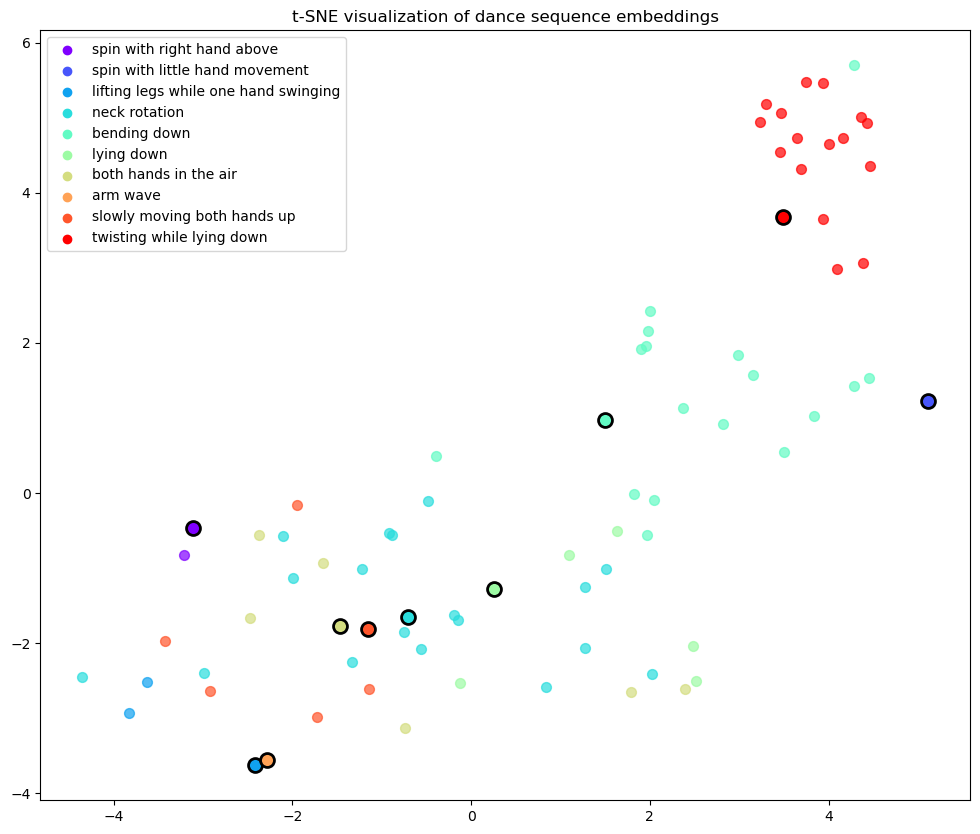

Average prediction confidence: 0.95
Number of low confidence predictions (<0.7): 10

Labeling Results:
Sequence | Label | Confidence
--------------------------
       0 | spin with little hand movement | Manual
       1 | spin with right hand above | Manual
       2 | lifting legs while one hand swinging | Manual
       3 | arm wave   | Manual
       4 | slowly moving both hands up | Manual
       5 | both hands in the air | Manual
       6 | bending down | Manual
       7 | neck rotation | Manual
       8 | lying down | Manual
       9 | twisting while lying down | Manual
      10 | twisting while lying down | 1.00
      11 | neck rotation | 1.00
      12 | neck rotation | 1.00
      13 | slowly moving both hands up | 0.67
      14 | slowly moving both hands up | 1.00
      15 | both hands in the air | 1.00
      16 | both hands in the air | 1.00
      17 | both hands in the air | 0.66
      18 | neck rotation | 0.67
      19 | both hands in the air | 1.00


In [122]:
dance_sequences = data
# Example manual labels for first 10 sequences
manual_labels = [
    "spin with little hand movement", "spin with right hand above", "lifting legs while one hand swinging", "arm wave", "slowly moving both hands up",
    "both hands in the air", "bending down", "neck rotation", "lying down", "twisting while lying down"
]

# Run semi-supervised labeling
all_labels, confidence_scores = semi_supervised_labeling(
    dance_sequences, manual_labels
)

# Display results for first few sequences
print("\nLabeling Results:")
print("Sequence | Label | Confidence")
print("--------------------------")

for i in range(20):  # Show first 20 as example
    confidence = confidence_scores[i - len(manual_labels)] if i >= len(manual_labels) else 1.0
    confidence_str = f"{confidence:.2f}" if i >= len(manual_labels) else "Manual"
    print(f"{i:8d} | {all_labels[i]:10s} | {confidence_str}")


In [124]:
data.shape

torch.Size([80, 50, 159])

In [226]:
for i in range(10):
    da = data[i,:,:]
    visualize(da,filename='label'+str(i))

100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 65.40it/s]


Saved animate/label0.gif and animate/label0.mp4


100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 83.76it/s]


Saved animate/label1.gif and animate/label1.mp4


100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 80.54it/s]


...

Saved animate/label7.gif and animate/label7.mp4


100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 79.54it/s]


Saved animate/label8.gif and animate/label8.mp4


100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 78.02it/s]


Saved animate/label9.gif and animate/label9.mp4


In [43]:
# example of semi supervised labelled data : 

In [126]:
idx=17
da = data[idx,:,:]
visualize(da,filename='label')

100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 81.12it/s]


Saved animate/label.gif and animate/label.mp4


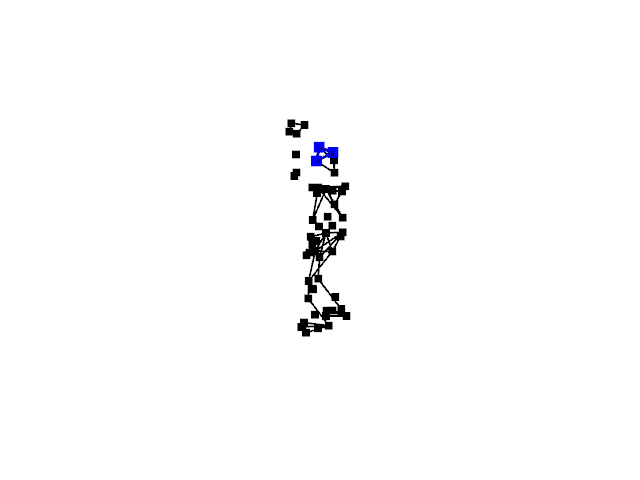

In [128]:
Image(filename='animate/label.gif')

In [130]:
# label of above gif 
all_labels[idx]

'both hands in the air'

In [132]:
all_labels

['spin with little hand movement',
 'spin with right hand above',
 'lifting legs while one hand swinging',
 'arm wave',
 'slowly moving both hands up',
 'both hands in the air',
 'bending down',
 'neck rotation',
 'lying down',
 'twisting while lying down',
 'twisting while lying down',
 'neck rotation',
 'neck rotation',
 'slowly moving both hands up',
 'slowly moving both hands up',
 'both hands in the air',
 'both hands in the air',
 'both hands in the air',
 'neck rotation',
 'both hands in the air',
 'neck rotation',
 'neck rotation',
 'neck rotation',
 'neck rotation',
 'lying down',
 'neck rotation',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'bending down',
 'twisting while lying down',
 'twisting while lying down',
 'twisting while lying down',
 'twisting while lying down',
 'twisting while lying down',
 'twisting while lying down',
 'twisting while lying down',
 'twisting while lying down',
 'twisting while lying down',
 'twisting wh

In [683]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from transformers import BertModel, BertTokenizer
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

class TextEncoder(nn.Module):
    def __init__(self, output_dim=8):
        super(TextEncoder, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.projection = nn.Linear(768, output_dim)
        
    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]
        embedding = self.projection(cls_output)
        # return embedding
        return nn.functional.normalize(embedding, p=2, dim=1)

# class DanceProjection(nn.Module):
#     def __init__(self, input_dim=64, output_dim=64):
#         super(DanceProjection, self).__init__()
#         self.projection = nn.Linear(input_dim, output_dim)
        
#     def forward(self, x):
#         embedding = self.projection(x)
#         return nn.functional.normalize(embedding, p=2, dim=1)

class ContrastiveDataset(Dataset):
    def __init__(self, text_labels, dance_embeddings, tokenizer, max_length=128):
        self.text_labels = text_labels
        self.dance_embeddings = dance_embeddings
        self.tokenizer = tokenizer
        self.max_length = max_length
        
    def __len__(self):
        return len(self.text_labels)
    
    def __getitem__(self, idx):
        text = self.text_labels[idx]
        dance_emb = self.dance_embeddings[idx]
        
        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_length,
            padding='max_length',
            return_tensors='pt'
        )
        
        return {
            'text': text,
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'dance_embedding': torch.tensor(dance_emb, dtype=torch.float32)
        }

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super(NTXentLoss, self).__init__()
        self.temperature = temperature
        self.criterion = nn.CrossEntropyLoss()
        
    def forward(self, text_embeddings, dance_embeddings):
        batch_size = text_embeddings.size(0)
        
        similarity_matrix = torch.matmul(text_embeddings, dance_embeddings.T) / self.temperature
        
        labels = torch.arange(batch_size).to(similarity_matrix.device)
        text_loss = self.criterion(similarity_matrix, labels)
        dance_loss = self.criterion(similarity_matrix.T, labels)
        
        return (text_loss + dance_loss) / 2

def train_model(text_labels, dance_embeddings, batch_size=16, epochs=30, lr=1e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    
    dataset = ContrastiveDataset(text_labels, dance_embeddings, tokenizer)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    text_encoder = TextEncoder().to(device)
    dance_projection = MotionAutoencoder().to(device)
    
    # criterion = NTXentLoss(temperature=0.7)
    criterion = torch.nn.MSELoss(reduction='mean')
    optimizer = optim.Adam([
        {'params': text_encoder.parameters(), 'lr': lr},
        {'params': dance_projection.parameters(), 'lr': lr}
    ])
    
    loss_history = []
    
    for epoch in range(epochs):
        text_encoder.train()
        dance_projection.train()
        epoch_loss = 0
        
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            dance_emb = batch['dance_embedding'].to(device)
            
            optimizer.zero_grad()
            
            text_emb = text_encoder(input_ids, attention_mask)
            print(dance_emb.shape)
            # dance_proj = dance_projection.encode(dance_emb)
            dance_proj = dance_emb.detach()
            print(text_emb)
            loss = criterion(text_emb, dance_proj)
            
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        avg_loss = epoch_loss / len(dataloader)
        loss_history.append(avg_loss)
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    
    plt.figure(figsize=(10, 5))
    plt.plot(loss_history)
    plt.title('Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.savefig('loss_curve.png')
    plt.show()
    plt.close()
    
    return text_encoder, dance_projection, loss_history

def visualize_embeddings(text_encoder, dance_projection, text_labels, dance_embeddings):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    
    text_encoder.eval()
    dance_projection.eval()
    
    with torch.no_grad():
        all_text_embs = []
        all_dance_embs = []
        
        for i in range(len(text_labels)):
            text = text_labels[i]
            dance_emb = dance_embeddings[i]
            
            encoding = tokenizer(
                text,
                truncation=True,
                max_length=128,
                padding='max_length',
                return_tensors='pt'
            )
            
            input_ids = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)
            dance_tensor = torch.tensor(dance_emb, dtype=torch.float32).unsqueeze(0).to(device)
            
            text_emb = text_encoder(input_ids, attention_mask)
            dance_proj = dance_tensor
            
            all_text_embs.append(text_emb.cpu().numpy())
            all_dance_embs.append(dance_proj.cpu().numpy())
    
    all_text_embs = np.vstack(all_text_embs)
    all_dance_embs = np.vstack(all_dance_embs)
    
    combined_embs = np.vstack([all_text_embs, all_dance_embs])
    
    tsne = TSNE(n_components=2, random_state=42,method='exact',n_jobs=1,perplexity=1)
    tsne_embs = tsne.fit_transform(combined_embs)
    
    n = len(text_labels)
    plt.figure(figsize=(10, 8))
    
    plt.scatter(tsne_embs[:n, 0], tsne_embs[:n, 1], c='blue', label='Text')
    plt.scatter(tsne_embs[n:, 0], tsne_embs[n:, 1], c='red', label='Dance')
    
    for i in range(n):
        plt.plot([tsne_embs[i, 0], tsne_embs[i+n, 0]], 
                 [tsne_embs[i, 1], tsne_embs[i+n, 1]], 'k-', alpha=0.3)
        plt.text(tsne_embs[i, 0], tsne_embs[i, 1], i, fontsize=9)
    
    plt.legend()
    plt.title('t-SNE visualization of text and dance embeddings')
    plt.savefig('embedding_visualization.png')
    plt.show()
    plt.close()

def calculate_retrieval_accuracy(text_encoder, dance_projection, text_labels, dance_embeddings):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    
    text_encoder.eval()
    dance_projection.eval()
    
    with torch.no_grad():
        all_text_embs = []
        all_dance_embs = []
        
        for i in range(len(text_labels)):
            text = text_labels[i]
            dance_emb = dance_embeddings[i]
            
            encoding = tokenizer(
                text,
                truncation=True,
                max_length=128,
                padding='max_length',
                return_tensors='pt'
            )
            
            input_ids = encoding['input_ids'].to(device)
            attention_mask = encoding['attention_mask'].to(device)
            dance_tensor = torch.tensor(dance_emb, dtype=torch.float32).unsqueeze(0).to(device)
            
            text_emb = text_encoder(input_ids, attention_mask)
            dance_proj = dance_tensor
            
            all_text_embs.append(text_emb.cpu().numpy())
            all_dance_embs.append(dance_proj.cpu().numpy())
    
    all_text_embs = np.vstack(all_text_embs)
    all_dance_embs = np.vstack(all_dance_embs)
    
    similarity = np.matmul(all_text_embs, all_dance_embs.T)
    
    text_to_dance_accuracy = 0
    dance_to_text_accuracy = 0
    
    for i in range(len(text_labels)):
        if np.argmax(similarity[i]) == i:
            text_to_dance_accuracy += 1
        if np.argmax(similarity[:, i]) == i:
            dance_to_text_accuracy += 1
    
    text_to_dance_accuracy /= len(text_labels)
    dance_to_text_accuracy /= len(text_labels)
    
    print(f"Text → Dance retrieval accuracy: {text_to_dance_accuracy:.4f}")
    print(f"Dance → Text retrieval accuracy: {dance_to_text_accuracy:.4f}")
    print(f"Average retrieval accuracy: {(text_to_dance_accuracy + dance_to_text_accuracy) / 2:.4f}")
    
    return text_to_dance_accuracy, dance_to_text_accuracy

In [685]:
model

MotionAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=7950, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=7950, bias=True)
  )
)

In [687]:
text_labels = all_labels[:1]
model.eval()
dance_embeddings = model.encode(data[:1]).detach()
model.train()
# dance_embeddings = dance_embeddings.detach() / np.linalg.norm(dance_embeddings.detach(), axis=1, keepdims=True)

MotionAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=7950, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=7950, bias=True)
  )
)

In [634]:
import torch
import numpy as np

# Compute mean and std
dance_embeddings = dance_embeddings.detach()
mean = dance_embeddings.mean(dim=0, keepdim=True)
std = dance_embeddings.std(dim=0, keepdim=True)

# Normalize
normalized_embeddings = (dance_embeddings - mean) / (std + 1e-8)

# Save mean and std for later use
torch.save({'mean': mean, 'std': std}, 'dance_embeddings_norm.pth')

# Restore mean and std
saved_data = torch.load('dance_embeddings_norm.pth')
mean_loaded = saved_data['mean']
std_loaded = saved_data['std']

# Function to restore original embeddings
def denormalize_embeddings(normalized_embeddings, mean, std):
    return normalized_embeddings * (std + 1e-8) + mean

# Restore original embeddings
restored_embeddings = denormalize_embeddings(normalized_embeddings, mean_loaded, std_loaded)

# Check if restoration is correct
# assert torch.allclose(restored_embeddings, dance_embeddings, atol=1e-6), "Restoration is incorrect"

In [645]:
dance_embeddings.shape

torch.Size([1, 8])

Using device: cpu
torch.Size([1, 8])
tensor([[ 0.1271,  0.3917,  0.1735, -0.5091, -0.1720,  0.2801, -0.6512,  0.0948]],
       grad_fn=<DivBackward0>)
Epoch 1/15, Loss: nan
torch.Size([1, 8])
tensor([[nan, nan, nan, nan, nan, nan, nan, nan]], grad_fn=<DivBackward0>)
Epoch 2/15, Loss: nan
torch.Size([1, 8])
tensor([[nan, nan, nan, nan, nan, nan, nan, nan]], grad_fn=<DivBackward0>)
Epoch 3/15, Loss: nan
torch.Size([1, 8])
tensor([[nan, nan, nan, nan, nan, nan, nan, nan]], grad_fn=<DivBackward0>)
Epoch 4/15, Loss: nan
torch.Size([1, 8])
tensor([[nan, nan, nan, nan, nan, nan, nan, nan]], grad_fn=<DivBackward0>)
Epoch 5/15, Loss: nan
torch.Size([1, 8])
tensor([[nan, nan, nan, nan, nan, nan, nan, nan]], grad_fn=<DivBackward0>)
Epoch 6/15, Loss: nan
torch.Size([1, 8])
tensor([[nan, nan, nan, nan, nan, nan, nan, nan]], grad_fn=<DivBackward0>)
Epoch 7/15, Loss: nan
torch.Size([1, 8])
tensor([[nan, nan, nan, nan, nan, nan, nan, nan]], grad_fn=<DivBackward0>)
Epoch 8/15, Loss: nan
torch.Size([1, 

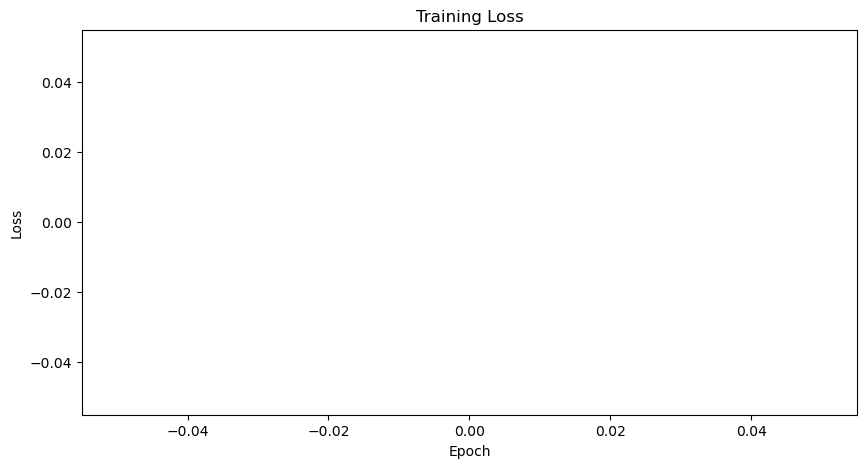

In [643]:
# Train the model
text_encoder, dance_projection, loss_history = train_model(
text_labels, 
normalized_embeddings,
batch_size=2, 
epochs=15,
    lr=1e-5)

In [566]:
dance_embeddings[0]

tensor([ -4.2389,  11.0839,   8.7288, -18.4541,  -4.0784,   3.6576, -17.7304,
         14.3766])

In [689]:
# Save models
torch.save(text_encoder.state_dict(), 'text_encoder.pth')
torch.save(dance_projection.state_dict(), 'dance_projection.pth')

# Visualize embeddings
visualize_embeddings(text_encoder, dance_projection, text_labels, dance_embeddings)

# Calculate retrieval accuracy
calculate_retrieval_accuracy(text_encoder, dance_projection, text_labels, dance_embeddings)

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 8 and the array at index 1 has size 32

In [570]:
# dp(torch.tensor(dance_embeddings[:1]))

In [571]:
# dp(torch.tensor(dance_embedding))

In [572]:
#Generating a dance sequence from a natural language input 

In [573]:
import torch
import numpy as np
from transformers import BertTokenizer

# Load trained models (assuming models are saved as 'text_encoder.pth' and 'dance_projection.pth')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

text_encoder = TextEncoder().to(device)
# dance_projection = DanceProjection().to(device)

text_encoder.load_state_dict(torch.load("text_encoder.pth", map_location=device))
# dance_projection.load_state_dict(torch.load("dance_projection.pth", map_location=device))

text_encoder.eval()
dance_projection.eval()

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

# Sample small holdout test set
test_texts = ["Graceful ballet spin", "Hip-hop pop and lock"]
test_dance_sequences = [np.random.rand(64), np.random.rand(64)]  # Placeholder embeddings

# Example 1: Generate a dance sequence from text
def generate_dance_from_text(text):
    with torch.no_grad():
        encoding = tokenizer(
            text, truncation=True, max_length=128, padding='max_length', return_tensors='pt'
        ).to(device)
        
        text_emb = text_encoder(encoding['input_ids'], encoding['attention_mask'])
        return text_emb.cpu().numpy()

dance_embedding = generate_dance_from_text("spin with little hand movement")
print("Generated Dance Sequence (Embedding):", dance_embedding)

Generated Dance Sequence (Embedding): [[ -4.849292    7.9583654   7.3091116 -11.011322   -4.427979    4.40342
  -10.537933    9.089239 ]]


In [574]:
# mdl = MotionAutoencoder()

In [579]:
# mdl

In [580]:
model.decode(torch.tensor(dance_embedding)).shape

torch.Size([1, 50, 159])

In [581]:
# dance_projection(torch.tensor(dance_embedding))

In [582]:
text_labels

['spin with little hand movement']

In [583]:
# # Example 2: Generate text from a dance sequence
# def generate_text_from_dance(dance_emb):
#     with torch.no_grad():
#         dance_tensor = torch.tensor(dance_emb, dtype=torch.float32).unsqueeze(0).to(device)
#         dance_proj = dance_projection(dance_tensor)

#         similarities = np.matmul(dance_proj.cpu().numpy(), np.vstack(test_dance_sequences).T)
#         best_match_idx = np.argmax(similarities)
#         return test_texts[best_match_idx]

# retrieved_text = generate_text_from_dance(test_dance_sequences[0])
# print("Generated Text from Dance:", retrieved_text)

In [584]:
dance_embedding.shape

(1, 8)

In [585]:
dance_embeddings.shape

torch.Size([1, 8])

In [586]:
out = model.decode(torch.tensor(dance_embedding))

In [589]:
dance_embedding.shape

(1, 8)

In [599]:
dance_embeddings[0].shape

torch.Size([8])

In [601]:
out.shape

torch.Size([1, 50, 159])

In [603]:
out

tensor([[[ 0.2109,  1.8856,  0.9704,  ...,  0.0418,  1.5844,  0.8017],
         [ 0.1940,  1.7213,  0.9126,  ...,  0.1446,  1.6583,  0.5692],
         [-0.0564,  1.8921,  0.8652,  ...,  0.1891,  1.6588,  0.8325],
         ...,
         [-0.0088,  0.3209,  1.1733,  ...,  0.0024,  0.4177,  0.7791],
         [ 0.2129,  0.5914,  1.0649,  ..., -0.2425,  0.5867,  0.6899],
         [ 0.1858,  0.3894,  0.9937,  ..., -0.1560,  0.5981,  0.7380]]],
       grad_fn=<ViewBackward0>)

In [605]:
out2 = model.decode(torch.tensor(dance_embeddings))

In [607]:
out2.shape

torch.Size([1, 50, 159])

In [609]:
data.shape

torch.Size([80, 50, 159])

In [611]:
data[1].shape

torch.Size([50, 159])

In [613]:
tem = model.encode(torch.tensor(data[:1]))
tem

tensor([[ -4.2389,  11.0839,   8.7288, -18.4541,  -4.0784,   3.6576, -17.7304,
          14.3766]], grad_fn=<AddmmBackward0>)

In [615]:
visualize(out.squeeze(0))
# visualize(out2.squeeze(0))
# visualize(model.decode(model.encode(torch.tensor(data[:1]))+0.1).squeeze(0))

100%|██████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 74.49it/s]


Saved animate/temppp.gif and animate/temppp.mp4


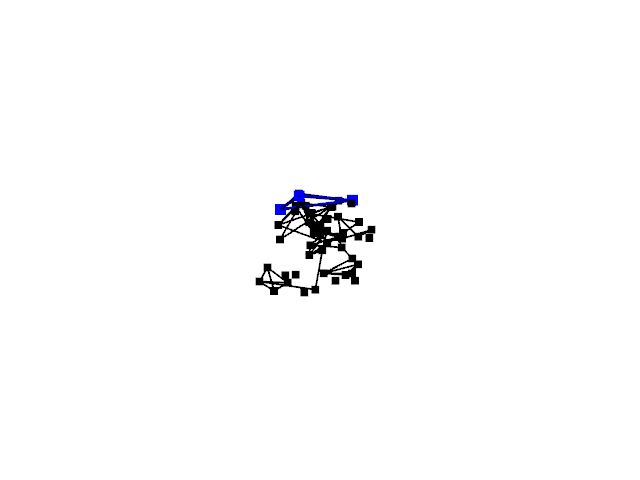

In [616]:
Image(filename='animate/temppp.gif')